<a href="https://colab.research.google.com/github/arbutler2003/Pneuomonia-Detection-CNN/blob/main/chest_xray_pneumonia_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Chest X-Ray Pneumonia Detection CNN**
## **Overview**
-TODO

## **Setup**

In [1]:
import os
from google.colab import userdata, drive

os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')

drive.mount('/content/drive')

ROOT_PATH = '/content'
ORIGINAL_DATASET = os.path.join(ROOT_PATH, 'chest_xray')
GOOGLE_DRIVE_PATH = '/content/drive/MyDrive/AidenB-Capstone-Sp2026'
REPO_PATH = os.path.join(GOOGLE_DRIVE_PATH, 'github')

# Download dataset to the local runtime
if not os.path.exists(ORIGINAL_DATASET):
  !kaggle datasets download -d paultimothymooney/chest-xray-pneumonia -p $ROOT_PATH
  print('Unzipping...')
  !unzip -q $ROOT_PATH/chest-xray-pneumonia.zip -d $ROOT_PATH -x '*__MACOSX*' -x 'chest_xray/chest_xray/*'
  !rm $ROOT_PATH/chest-xray-pneumonia.zip
  print('Download complete.')
else:
  print('Dataset present.')

Mounted at /content/drive
Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
 96% 2.20G/2.29G [00:20<00:02, 46.1MB/s]
100% 2.29G/2.29G [00:20<00:00, 122MB/s] 
Unzipping...
caution: excluded filename not matched:  -x
Download complete.


## **Dataset Restructuring**
This section addresses the dataset's disproportional subsets for training, validation, and testing.

---

The dataset only contains 16 X-ray images in the 'val' subset, which is not nearly enough for validation. The main reason is because a single mistake in validation would cause a substantial drop in performance metrics. To address this, we'll use a script to combine the 'train' and 'val' subsets and redistribute to an 80/20 split, respectively. We want to leave the 'test' subset untouched, as the dataset contains some sets of X-rays from the same patient over the span of their hospital visit. This is a form of data leakage and can lead to boosted metrics, as the model can memorize the patient rather than the features.

In [2]:
import os
import glob
import random
import shutil

# To hold the dataset with the new split
MODIFIED_DATASET = '/content/working_dataset'

# Create the two pools
pneumonia_pool = glob.glob(os.path.join(ROOT_PATH, 'chest_xray/train/PNEUMONIA/*')) + \
                 glob.glob(os.path.join(ROOT_PATH, 'chest_xray/val/PNEUMONIA/*'))

normal_pool = glob.glob(os.path.join(ROOT_PATH, 'chest_xray/train/NORMAL/*')) + \
              glob.glob(os.path.join(ROOT_PATH, 'chest_xray/val/NORMAL/*'))

# Ensure randomness
random.shuffle(pneumonia_pool)
random.shuffle(normal_pool)

pneumonia_index = int(len(pneumonia_pool) * 0.8)
normal_index = int(len(normal_pool) * 0.8)

# Build the new partitions
train_pneumonia = pneumonia_pool[:pneumonia_index]
val_pneumonia = pneumonia_pool[pneumonia_index:]

train_normal = normal_pool[:normal_index]
val_normal = normal_pool[normal_index:]

# Helper function to copy each list of images to it's respective directory
def copy_to_working_directory(file_list, split_type, class_name):
  """
  Copies a list of images to the specified directory. Currently uses shutil.copy()
  to prevent the script from crashing if re-run, however, shutil.move() can be used
  to save space.

  Args:
    file_list: A list of file paths
    split_type: 'train' or 'val'
    class_name: 'PNEUMONIA' or 'NORMAL'
  """
  destination_dir = os.path.join(MODIFIED_DATASET, split_type, class_name)
  os.makedirs(destination_dir, exist_ok=True)

  for file_path in file_list:
    shutil.copy(file_path, destination_dir)

# Call the helper function to populate the subdirectories
copy_to_working_directory(train_pneumonia, 'train', 'PNEUMONIA')
copy_to_working_directory(val_pneumonia, 'val', 'PNEUMONIA')

copy_to_working_directory(train_normal, 'train', 'NORMAL')
copy_to_working_directory(val_normal, 'val', 'NORMAL')

This section displays the class discrency in the dataset and calculates their respective weights.

---

In this dataset, 'Pneumonia' x-ray images make up 73% of the data, with the remaining 27% being 'Normal'. The concern with a class imbalance during training is that the model may learn to guess 'Pneumonia" due to the higher than even statistical probability. We will prevent this by applying class weights, so that 'Normal' images are weighted heavier. These weights are used during training with our loss function to penalize the model harsher when it misclassifies the minority class, in this case 'Normal'.


Class Weights (0:Normal, 1:Pneumonia): {0: 1.9392956441149212, 1: 0.6736960721184804}


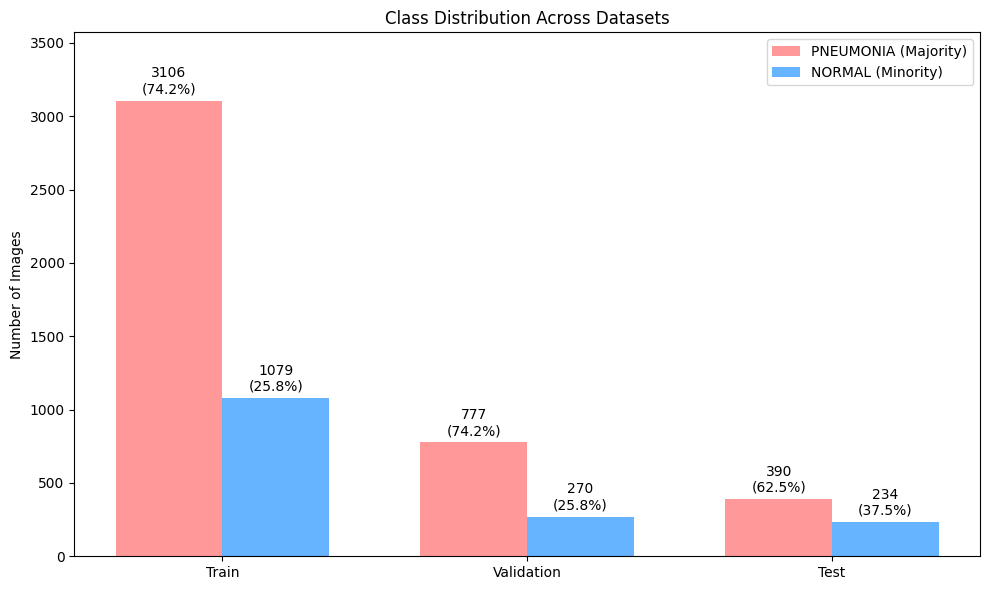

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import glob
import os

# Gather class counts across all subsets
train_pneumonia_count = len(glob.glob(os.path.join(MODIFIED_DATASET, 'train/PNEUMONIA/*')))
train_normal_count = len(glob.glob(os.path.join(MODIFIED_DATASET, 'train/NORMAL/*')))

val_pneumonia_count = len(glob.glob(os.path.join(MODIFIED_DATASET, 'val/PNEUMONIA/*')))
val_normal_count = len(glob.glob(os.path.join(MODIFIED_DATASET, 'val/NORMAL/*')))

test_pneumonia_count = len(glob.glob(os.path.join(ORIGINAL_DATASET, 'test/PNEUMONIA/*')))
test_normal_count = len(glob.glob(os.path.join(ORIGINAL_DATASET, 'test/NORMAL/*')))

# Calculate class weights
train_total = train_pneumonia_count + train_normal_count

weight_for_normal = (1 / train_normal_count) * (train_total / 2.0)
weight_for_pneumonia = (1 / train_pneumonia_count) * (train_total / 2.0)

class_weight = {0: weight_for_normal, 1: weight_for_pneumonia}
print(f"Class Weights (0:Normal, 1:Pneumonia): {class_weight}")

#=====Graph====
labels = ['Train', 'Validation', 'Test']
pneumonia_counts = [train_pneumonia_count, val_pneumonia_count, test_pneumonia_count]
normal_counts = [train_normal_count, val_normal_count, test_normal_count]

# Calculate totals for each subset to find the percentages
totals = [p + n for p, n in zip(pneumonia_counts, normal_counts)]

# Create custom labels with count and percentage
pneumonia_labels = [f"{count}\n({(count/total)*100:.1f}%)" for count, total in zip(pneumonia_counts, totals)]
normal_labels = [f"{count}\n({(count/total)*100:.1f}%)" for count, total in zip(normal_counts, totals)]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, pneumonia_counts, width, label='PNEUMONIA (Majority)', color='#ff9999')
rects2 = ax.bar(x + width/2, normal_counts, width, label='NORMAL (Minority)', color='#66b3ff')

ax.set_ylabel('Number of Images')
ax.set_title('Class Distribution Across Datasets')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

ax.bar_label(rects1, labels=pneumonia_labels, padding=3)
ax.bar_label(rects2, labels=normal_labels, padding=3)

ax.set_ylim(0, max(pneumonia_counts) * 1.15)

plt.tight_layout()
plt.show()

## **Preprocessing**
This section prepares the data by defining the directories, image specs, preprocessing the X-rays, and building the batch generators.


---
We use Kera's ResNet50 preprocessing function to prepare the X-ray images. Their function applies two main changes:
* The images' channel order are converted from RGB to BGR.
* The pixel values are zero-centered, which shifts the pixel range from (0, 255) to (-128, 128). During the training of ResNet50, the average value for every pixel in every image was calculated for each color channel. The x-ray pixel values are zero-centered by subtracting the corresponding average.




In [5]:
import os

# Define dataset subdirectories
train_dir = os.path.join(MODIFIED_DATASET, 'train')
val_dir = os.path.join(MODIFIED_DATASET, 'val')
test_dir = os.path.join(ORIGINAL_DATASET, 'test')

# Standard for models trained on ImageNet (i.e., ResNet)
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

In [6]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import preprocess_input

# Preprocessing function for ResNet models
datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

# Build generators for each subset
train_generator = datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

val_generator = datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

test_generator = datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

Found 4185 images belonging to 2 classes.
Found 1047 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


## **Preprocessing - Visualization**
This section shows a visual comparison between a sample of raw images and their preprocessed version.

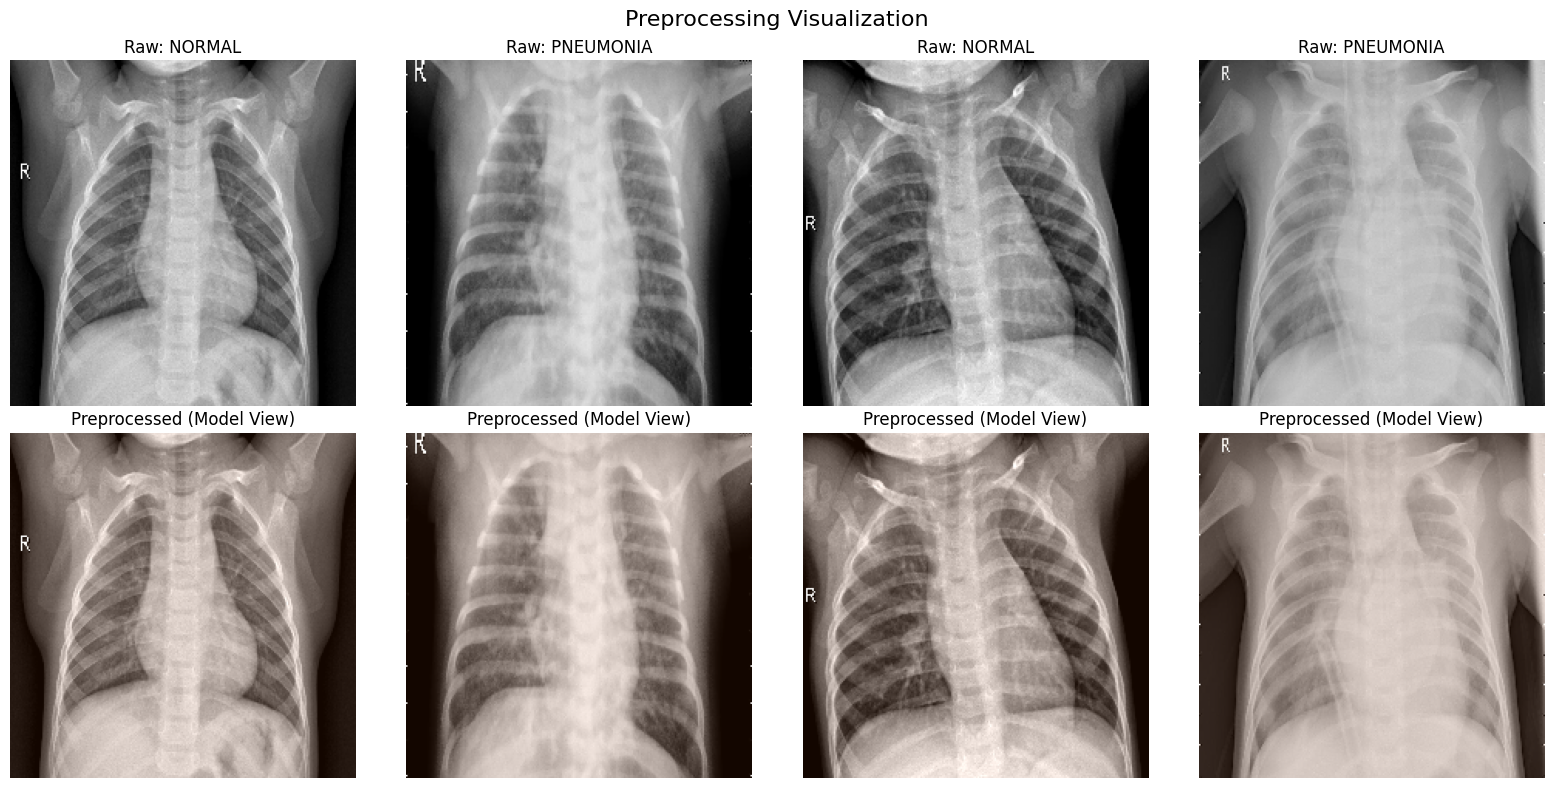

In [8]:
# @title
import matplotlib.pyplot as plt
import numpy as np

images, labels = next(train_generator)

def deprocess_to_raw(img):
    img = img.copy()
    img[..., 0] += 103.939
    img[..., 1] += 116.779
    img[..., 2] += 123.68
    img = img[..., ::-1]
    return np.clip(img, 0, 255) / 255.0

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i in range(4):
    label_name = 'PNEUMONIA' if labels[i] == 1.0 else 'NORMAL'

    # Raw
    axes[0, i].imshow(deprocess_to_raw(images[i]))
    axes[0, i].set_title(f'Raw: {label_name}')
    axes[0, i].axis('off')

    # Preprocessed
    display_preprocessed = np.clip((images[i] + 123.68) / 255.0, 0, 1)
    axes[1, i].imshow(display_preprocessed)
    axes[1, i].set_title(f'Preprocessed (Model View)')
    axes[1, i].axis('off')

plt.suptitle("Preprocessing Visualization", fontsize=16)
plt.tight_layout()
plt.show()

## **Model Creation**
This section instantiates a ResNet50 model for the base layers, and specifies our custom classification head.


---

Here we are using the base layers of the ResNet50 model, which is trained to extract features from images (e.g, shadows or edges). We will extend this model with a top classifying layer to determine which features are relevant, such as shadows from moisture. The complexity going on here is in creating the custom head.
* The ResNet50 (our base model) outputs a block of features with the shape (7, 7, 2048). This can be imagined as a stack of 2,048 different 7x7 images of features that we want to capture as input. To do so, we need to use GlobalAveragePooling2D() to convert ResNet50's 3D vector output into a 1D vector. Keras does this by averaging the value of the pixels within each 49 pixel grid, resulting in a vector containing the 2,048 averages.
* The following dense layer can be thought of as the judge, which evaluates the 2,048 inputs and their corresponding weights. The result is a number (e.g., 5 or -2.7) and we need to scale the range to 0-1 for probability interpretation; to do this, we'll use the sigmoid activation function. After this, we have a single value to reflect the models' determined probability of pneomonia.

In [9]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from keras.applications.resnet50 import ResNet50

base_model = keras.applications.ResNet50(
    include_top = False, # Exclude ImageNet classification layer
    weights = 'imagenet', # Pre-trained on ImageNet
    input_shape = (224, 224, 3)
)

# Freeze the base layer
base_model.trainable = False

# Create the head of the model
inputs = keras.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = keras.layers.GlobalAveragePooling2D()(x)
outputs = keras.layers.Dense(1, activation='sigmoid')(x)

model = keras.Model(inputs, outputs)
model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         2,049 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,589,761 (89.99 MB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

## **Feature Vector - Visualization**
This section visualizes the output of the Global Average Pooling (GAP) layer.

---

As discussed previously, the GAP function returns a vector of 2048 single values representing the features identified. The 32x64 grid represents each of the values in the vector. The color of the pixel represents each value, using purple for inactive features and green/yellow for strong features. It's important to note that the layout of the grid doesn't map directly to the orientation of the image, so we can see if there are strong features identified, but not where on the original image. The vast majority of the images will have similar grids, as most of the features are generic (i.e., rib cage, background, high-contrast edges). The model learns to weigh these features lightly, and emphasize the feature values that are different. An example may be the yellow pixel that appears in the lower-left quadrant of the 'Pneumonia' grid, which doesn't appear in the 'Normal' grid.

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


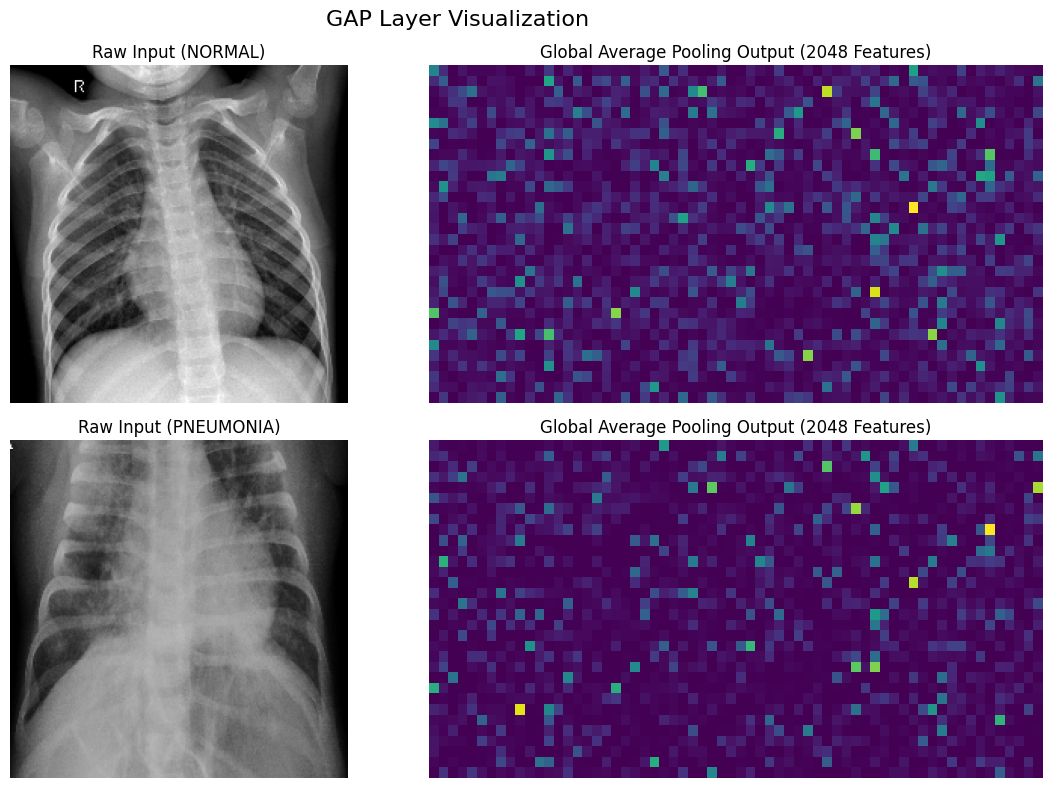

In [16]:
import matplotlib.pyplot as plt
import numpy as np
from tensorflow import keras

feature_extractor = keras.Model(inputs=model.input, outputs=model.layers[2].output)

images, labels = next(train_generator)
selected_indices = [np.where(labels == 0)[0][0], np.where(labels == 1)[0][0]]
selected_images = images[selected_indices]
vectors = feature_extractor.predict(selected_images)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for row, idx in enumerate(selected_indices):
    label_name = 'PNEUMONIA' if labels[idx] == 1.0 else 'NORMAL'

    # Show Raw
    axes[row, 0].imshow(deprocess_to_raw(images[idx]))
    axes[row, 0].set_title(f'Raw Input ({label_name})')
    axes[row, 0].axis('off')

    # Show Feature Vector
    vector_grid = vectors[row].reshape(32, 64)
    vector_grid = (vector_grid - vector_grid.min()) / (vector_grid.max() - vector_grid.min())
    im = axes[row, 1].imshow(vector_grid, cmap='viridis', aspect='auto')
    axes[row, 1].set_title('Global Average Pooling Output (2048 Features)')
    axes[row, 1].axis('off')

plt.suptitle("GAP Layer Visualization", fontsize=16)
plt.tight_layout()
plt.show()

## **Model Compilation**
This section handles the training settings for our custom head.


---

The optimizer adjusts the trainable parameters to better interpret the features that the frozen ResNet50 model serves us.
* A helpful analogy that I saw: The model is a hiker stranded on a jagged mountain on a foggy night trying to reach the bottom of the mountain, which represents minimum loss. The hiker feels the ground 32 times (batch size) to calculate average slope before changing the weights, and the learning rate is how large a step the hiker takes.
* The loss function we're using here is binary cross-entropy which operates on the principle of punishing confident wrongfulness; for example, the model is "punished" harsher for predicting 90% chance of pneumonia in a healthy patient than if it were to predict a 60% chance.

In [17]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.Recall(name='recall'),
        keras.metrics.Precision(name='precision'),
        keras.metrics.AUC(name='auc')
        ]
)

## **Model Training**
This section initiates the training process.

---

During training, the model iterates through the 'train' subset in cycles called epochs. Each epoch has these stages:


 ### 1. Training
 The model processes the images in batches of 32. For each batch, the model makes its prediction and compares that to the actual label to calculate the loss. The Adam optimizer adjusts the weights of the Dense layer to minimize that loss.
 ### 2. Validation
 At the end of each epoch, the model does an evaluation using the unseen 'val' subset. This is when our primary metric 'val_loss' is calculated.
 ### 3. Callbacks
 Once the 'val_loss' is calculated, we can use it to make decisions before the next epoch.

*    ModelCheckpoint: Saves the model if 'val_loss' is the lowest we've seen so far.

*    EarlyStopping: Stops the training if 'val_loss' doesn't improve over three consecutive epochs.






In [18]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

checkpoint = ModelCheckpoint(
    'best_model.keras', # File to save the best weights
    monitor='val_loss', # Loss is our primary metric
    mode='min', # We want to minimize loss
    save_best_only=True,
    verbose=1
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3, # Stop if there is no improvement after 3 epochs
    restore_best_weights=True
)

history = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator,
    class_weight=class_weight,
    callbacks=[checkpoint, early_stopping],
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 368ms/step - accuracy: 0.4988 - auc: 0.5836 - loss: 0.7169 - precision: 0.7703 - recall: 0.4095
Epoch 1: val_loss improved from inf to 0.38666, saving model to best_model.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 83s 530ms/step - accuracy: 0.5001 - auc: 0.5851 - loss: 0.7158 - precision: 0.7713 - recall: 0.4111 - val_accuracy: 0.8520 - val_auc: 0.9396 - val_loss: 0.3867 - val_precision: 0.9520 - val_recall: 0.8430
Epoch 2/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 325ms/step - accuracy: 0.8676 - auc: 0.9523 - loss: 0.3406 - precision: 0.9532 - recall: 0.8633
Epoch 2: val_loss improved from 0.38666 to 0.25663, saving model to best_model.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 54s 415ms/step - accuracy: 0.8677 - auc: 0.9524 - loss: 0.3403 - precision: 0.9533 - recall: 0.8635 - val_accuracy: 0.9198 - val_auc: 0.9777 - val_loss: 0.2566 - val_precision: 0.9753 - val_recall: 0.9151
Epoch 3/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step - accuracy: 0.9156 - auc: 0.9796 -

## **Training Visualization**
This section rebuilds the previous training logs and graphs them.

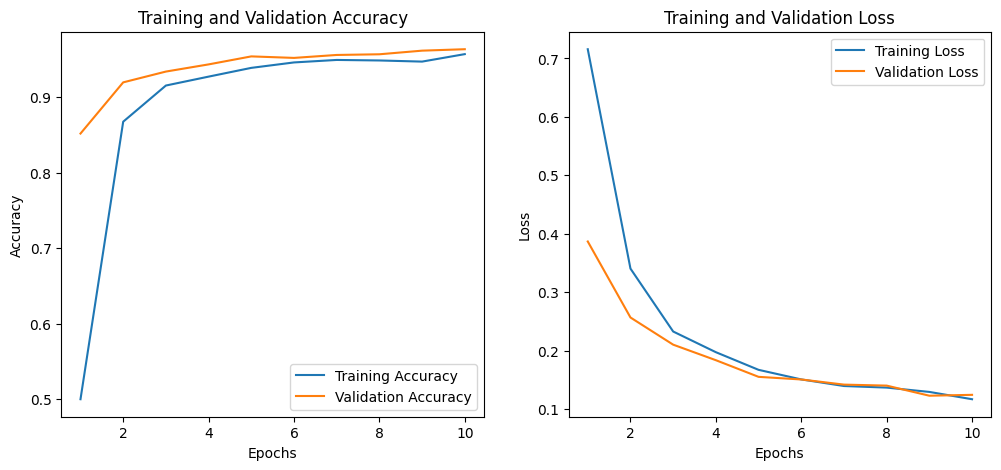

In [20]:
import matplotlib.pyplot as plt

# Manually reconstructed history from logs
class MockHistory:
    def __init__(self):
        self.history = {}

history = MockHistory()

# Epochs: 1, 2, 3, 4, 5, 6, 7, 8, 9, 10
history.history['accuracy'] =     [0.5001, 0.8677, 0.9156, 0.9274, 0.9390, 0.9462, 0.9495, 0.9488, 0.9473, 0.9572]
history.history['val_accuracy'] = [0.8520, 0.9198, 0.9341, 0.9436, 0.9542, 0.9522, 0.9561, 0.9570, 0.9618, 0.9637]
history.history['loss'] =         [0.7158, 0.3403, 0.2326, 0.1972, 0.1670, 0.1506, 0.1393, 0.1366, 0.1292, 0.1167]
history.history['val_loss'] =     [0.3867, 0.2566, 0.2101, 0.1835, 0.1550, 0.1505, 0.1417, 0.1400, 0.1227, 0.1242]

def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))

    # Plot Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')

    plt.show()

plot_history(history)

##**Testing**
This section evaluates the model on the 'test' subset and prints the final metrics.

In [19]:
# Load the best weights
model.load_weights('best_model.keras')

# Run evaluation
print("Evaluating on Test Set...")
test_results = model.evaluate(test_generator, verbose=1)

# In Keras 3, metrics are often bundled. Let's map them by their specific display names.
# test_results[0] is 'loss'
# test_results[1] is 'accuracy', [2] is 'recall', etc.
print("-" * 30)
print(f"Test Accuracy:  {test_results[1]:.2%} | The model was correct x% of the time")
print(f"Test Recall:    {test_results[2]:.2%} | The model found x% of the Pneumonia images")
print(f"Test Precision: {test_results[3]:.2%} | When the model determined Pneumonia, it was correct x% of the time")
print(f"Test AUC:       {test_results[4]:.4f} | The model correctly ranks a random positive image above a negative one x% of the time")
print("-" * 30)

Evaluating on Test Set...
20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 477ms/step - accuracy: 0.7557 - auc: 0.6296 - loss: 0.5475 - precision: 0.4334 - recall: 0.6423
------------------------------
Test Accuracy:  84.13% | The model was correct x% of the time
Test Recall:    96.92% | The model found x% of the Pneumonia images
Test Precision: 81.29% | When the model determined Pneumonia, it was correct x% of the time
Test AUC:       0.9460 | The model correctly ranks a random positive image above a negative one x% of the time
------------------------------


Save the model

In [21]:
import shutil

# Copy the best model to your Capstone folder on Drive
shutil.copy('best_model.keras', GOOGLE_DRIVE_PATH)

'/content/drive/MyDrive/AidenB-Capstone-Sp2026/best_model.keras'

Load Model

In [ ]:
from tensorflow.keras.models import load_model

model = load_model('/content/drive/MyDrive/AidenB-Capstone-Sp2026/best_model.keras')